3D House Price Regression Plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

Import the housing dataset

In [ ]:
file_path = "/content/House_Price_Prediction.csv"
df = pd.read_csv("/content/House_Price_Prediction.csv")
print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   Area (sq ft)  Number of Bedrooms  House Price
0          1000                   2           50
1          1200                   2           60
2          1500                   3           75
3          1800                   3           90
4          2000                   3          100


Select regression inputs and output

In [ ]:
X = df[['Area (sq ft)', 'Number of Bedrooms']]
y = df['House Price']

Train the linear regression model

In [ ]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

Generate the grid for the fitted surface

In [ ]:
area_range = np.linspace(df['Area (sq ft)'].min(), df['Area (sq ft)'].max(), 30)
bedroom_range = np.linspace(df['Number of Bedrooms'].min(), df['Number of Bedrooms'].max(), 30)
area_grid, bedroom_grid = np.meshgrid(area_range, bedroom_range)

Compute predicted prices on the grid

In [ ]:
price_pred = model.predict(np.column_stack((area_grid.ravel(), bedroom_grid.ravel())))
price_grid = price_pred.reshape(area_grid.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Plot data and fitted plane

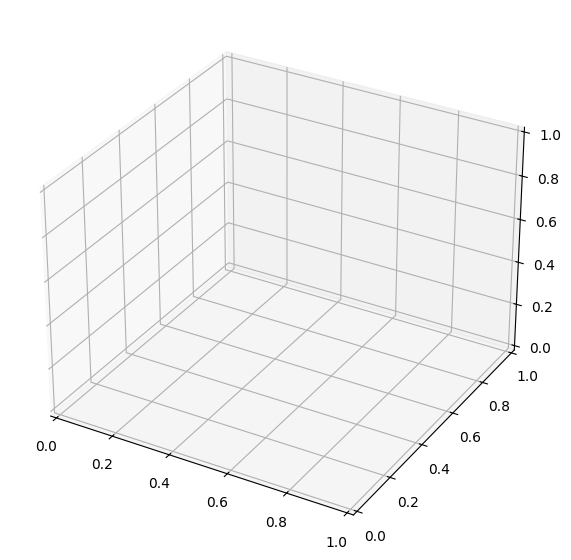

In [ ]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

Display the actual house price points

In [ ]:
ax.scatter(df['Area (sq ft)'], df['Number of Bedrooms'], df['House Price'],
           color='red', label='Actual Data', s=50)

Overlay the regression surface

In [ ]:
ax.plot_surface(area_grid, bedroom_grid, price_grid, alpha=0.5, cmap='viridis')

Set axis labels and title

Dataset loaded successfully!
   Area (sq ft)  Number of Bedrooms  House Price
0          1000                   2           50
1          1200                   2           60
2          1500                   3           75
3          1800                   3           90
4          2000                   3          100


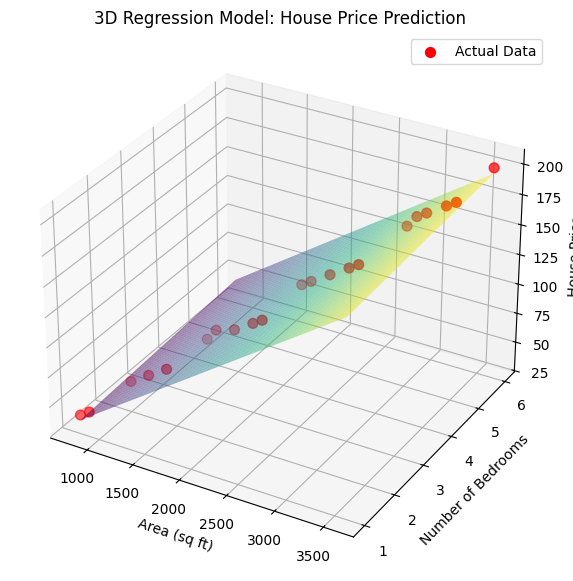

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Step 2: Load dataset
df = pd.read_csv("House_Price_Prediction.csv")   # <-- replace with your CSV path
print("Dataset loaded successfully!")
print(df.head())

# Step 3: Prepare features and target
X = df[['Area (sq ft)', 'Number of Bedrooms']]
y = df['House Price']

# Step 4: Fit regression model
model = LinearRegression()
model.fit(X, y)

# Step 5: Create grid for regression surface
area_range = np.linspace(df['Area (sq ft)'].min(), df['Area (sq ft)'].max(), 80)
bedroom_range = np.linspace(df['Number of Bedrooms'].min(), df['Number of Bedrooms'].max(), 80)
area_grid, bedroom_grid = np.meshgrid(area_range, bedroom_range)

# Predict prices for the grid
grid_df = pd.DataFrame(np.column_stack((area_grid.ravel(), bedroom_grid.ravel())),
                       columns=['Area (sq ft)', 'Number of Bedrooms'])
price_pred = model.predict(grid_df)
price_grid = price_pred.reshape(area_grid.shape)

# Step 6: Plot 3D scatter + regression surface
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Actual data points
ax.scatter(df['Area (sq ft)'], df['Number of Bedrooms'], df['House Price'],
           color='red', label='Actual Data', s=50)

# Regression surface
ax.plot_surface(area_grid, bedroom_grid, price_grid, alpha=0.5, cmap='viridis')

# Labels and title
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('House Price')
ax.set_title('3D Regression Model: House Price Model Visualization')

ax.legend()
plt.show()
